In [3]:
import math
from urllib.request import urlopen, Request

import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from mplsoccer import VerticalPitch, Sbopen, FontManager, inset_image

# data parser, fonts and path effects for giving the font an edge
parser = Sbopen()
roboto_bold = FontManager(
    'https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/RobotoSlab%5Bwght%5D.ttf')
path_eff = [path_effects.Stroke(linewidth=3, foreground='white'),
            path_effects.Normal()]


In [4]:
parser = Sbopen()
event, related, freeze, tactics = parser.event(3857283)

# Starting XI for belgium
starting_xi_event = event.loc[
    (event['type_name'] == 'Starting XI') &
    (event['team_name'] == 'Belgium'),
    ['id', 'tactics_formation']
]

starting_xi = tactics.merge(starting_xi_event, on='id')

# Morocco WC 2022 short names
player_short_names = {
    'Thibaut Courtois': 'Courtois',
    'Toby Alderweireld': 'Alderweireld',
    'Jan Vertonghen': 'Vertonghen',
    'Leander Dendoncker': 'Dendoncker',
    'Thomas Meunier': 'Meunier',
    'Kevin De Bruyne': 'De Bruyne',
    'Axel Witsel': 'Witsel',
    'Yannick Carrasco': 'Carrasco',
    'Eden Hazard': 'Hazard',
    'Dries Mertens': 'Mertens',
    'Romelu Lukaku': 'Lukaku',
}
starting_xi['player_name'] = starting_xi['player_name'].replace(player_short_names)

# Successful ball receipts from starting XI only
ball_receipts = event.loc[
    (event['type_name'] == 'Ball Receipt') &
    (event['outcome_name'].isnull()) &
    (event['player_id'].isin(starting_xi['player_id'])),
    ['player_id', 'x', 'y']
]

# Merge starting positions
event = ball_receipts.merge(starting_xi, on='player_id')
formation = event['tactics_formation'].iloc[0]

print(f"Formation: {formation}")
print(f"Players found: {event['player_name'].nunique()}")

Formation: 4231
Players found: 11


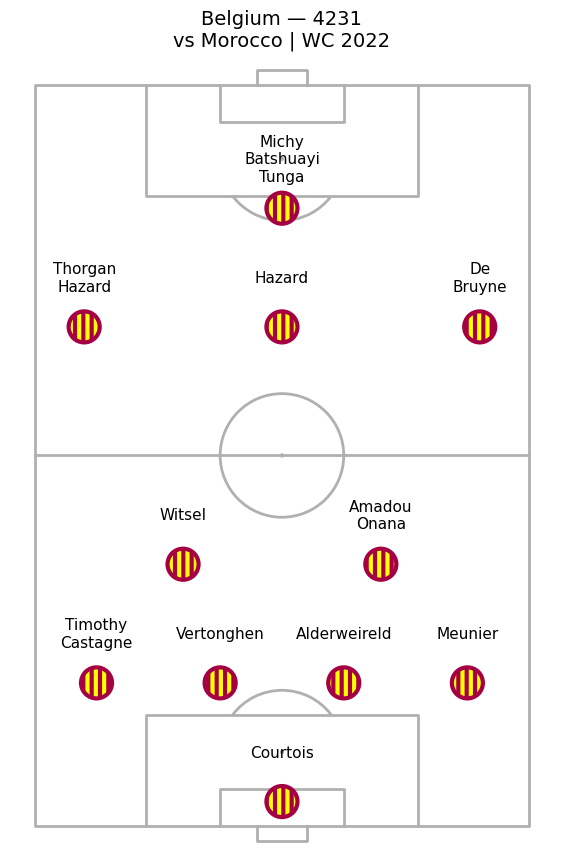

In [8]:
pitch = VerticalPitch(goal_type='box')
fig, ax = pitch.draw(figsize=(6, 8.72))

# Text labels
ax_text = pitch.formation(
    formation,
    positions=starting_xi.position_id,
    kind='text',
    text=starting_xi.player_name.str.replace(' ', '\n'),
    va='center',
    ha='center',
    fontsize=11,
    ax=ax
)

# Scatter markers  belguim colors)
mpl.rcParams['hatch.linewidth'] = 3
mpl.rcParams['hatch.color'] = '#FFFF00'  

ax_scatter = pitch.formation(
    formation,
    positions=starting_xi.position_id,
    kind='scatter',
    c='#a50044',          
    hatch='||',
    linewidth=3,
    s=500,
    xoffset=-8,
    ax=ax
)

ax.set_title(f"Belgium — {formation}\nvs Morocco | WC 2022", size=14, pad=10)
plt.tight_layout()
plt.show()